In [34]:
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt
import seaborn as sns
import sklearn



%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

pd. set_option('display.max_columns', 300)
pd. set_option('display.max_rows', 300)

In [79]:
read = pd.read_csv('H2HBABBA1887.csv')

In [80]:
df = pd.DataFrame(read)

In [81]:
df.isna().sum()

business_code                 0
cust_number                   0
name_customer                 0
clear_date                10000
buisness_year                 0
doc_id                        0
posting_date                  0
document_create_date          0
document_create_date.1        0
due_in_date                   0
invoice_currency              0
document type                 0
posting_id                    0
area_business             50000
total_open_amount             0
baseline_create_date          0
cust_payment_terms            0
invoice_id                    9
isOpen                        0
dtype: int64

In [82]:
# Removing NaN(area_bussiness) column
df = df.drop(['area_business'], axis=1)

In [83]:
df

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,posting_id,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen
0,U001,0200769623,WAL-MAR in,NaN,2020.0,1.930815e+09,2020-04-28,20200422,20200428,20200513.0,USD,RV,1.0,6361.07,20200428.0,NAH4,1.930815e+09,1
1,U001,0200729828,KENNETH foundation,2019-09-25 00:00:00,2019.0,1.929826e+09,2019-09-06,20190903,20190906,20190926.0,USD,RV,1.0,27848.46,20190906.0,NAD1,1.929826e+09,0
2,U001,CCU013,KRAFT F trust,NaN,2020.0,1.930666e+09,2020-03-16,20200317,20200316,20200316.0,USD,RV,1.0,5095.68,20200316.0,NAX2,1.930666e+09,1
3,U001,0200780383,MEIJ us,2019-09-30 00:00:00,2019.0,1.929852e+09,2019-09-09,20190909,20190909,20190924.0,USD,RV,1.0,81781.59,20190909.0,NAA8,1.929852e+09,0
4,U001,0200792293,UNIFIE llc,2019-11-22 00:00:00,2019.0,1.930113e+09,2019-11-05,20191105,20191105,20191120.0,USD,RV,1.0,67352.17,20191105.0,NAA8,1.930113e+09,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,U001,0200726979,BJ'S associates,2019-01-30 00:00:00,2019.0,1.928608e+09,2019-01-15,20190111,20190115,20190130.0,USD,RV,1.0,290.59,20190115.0,NAA8,1.928608e+09,0
49996,U001,0200705742,DOT us,2019-02-13 00:00:00,2019.0,1.928704e+09,2019-01-29,20190129,20190129,20190213.0,USD,RV,1.0,1957.09,20190129.0,NAA8,1.928704e+09,0
49997,U001,0200759878,SA systems,NaN,2020.0,1.930838e+09,2020-05-02,20200429,20200502,20200517.0,USD,RV,1.0,7595.36,20200502.0,NAH4,1.930838e+09,1
49998,U001,0200726979,BJ'S co,2020-03-09 00:00:00,2020.0,1.930560e+09,2020-02-22,20200224,20200222,20200308.0,USD,RV,1.0,522.38,20200222.0,NAA8,1.930560e+09,0


#### create date is target column

# Removing the datapoints where the target value is null

In [84]:
main_train = df[df.clear_date.isnull() == False]
main_test = df[df.clear_date.isnull() == True]

In [85]:
#Preprocess the data 
main_train.shape

(40000, 18)

In [86]:
main_train.isna().sum()

business_code             0
cust_number               0
name_customer             0
clear_date                0
buisness_year             0
doc_id                    0
posting_date              0
document_create_date      0
document_create_date.1    0
due_in_date               0
invoice_currency          0
document type             0
posting_id                0
total_open_amount         0
baseline_create_date      0
cust_payment_terms        0
invoice_id                9
isOpen                    0
dtype: int64

# Preprocessing

### Null Imputation

In [87]:
# Checking the column having NaN row 
main_train[main_train.invoice_id.isnull()]

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,posting_id,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen
8363,CA02,0140104409,LOB associates,2019-04-17 00:00:00,2019.0,9.500000e+09,2019-03-29,20190329,20190314,20190324.0,CAD,X2,1.0,698.60,20190314.0,CA10,NaN,0
12386,CA02,0140104409,LOB co,2019-12-27 00:00:00,2019.0,9.500000e+09,2019-03-29,20190329,20190228,20190310.0,CAD,X2,1.0,173.44,20190228.0,CA10,NaN,0
16029,CA02,0140104409,LOB associates,2019-12-27 00:00:00,2019.0,9.500000e+09,2019-03-29,20190329,20180626,20180706.0,CAD,X2,1.0,279.60,20180626.0,CA10,NaN,0
16348,CA02,0140106054,TREE trust,2019-05-31 00:00:00,2019.0,9.500000e+09,2019-03-29,20190329,20190307,20190317.0,CAD,X2,1.0,1751.14,20190307.0,CA10,NaN,0
27159,CA02,0140104429,COSTCO in,2019-05-14 00:00:00,2019.0,9.500000e+09,2019-03-29,20190329,20190311,20190321.0,CAD,X2,1.0,5353.20,20190311.0,CA10,NaN,0
35364,CA02,0140106054,TREE llc,2019-05-22 00:00:00,2019.0,9.500000e+09,2019-03-29,20190329,20190301,20190311.0,CAD,X2,1.0,21245.76,20190301.0,CA10,NaN,0
36289,CA02,0140106054,TREE llc,2019-05-06 00:00:00,2019.0,9.500000e+09,2019-03-29,20190329,20190208,20190218.0,CAD,X2,1.0,938.43,20190208.0,CA10,NaN,0
37333,CA02,0140106054,TREE in,2019-05-06 00:00:00,2019.0,9.500000e+09,2019-03-29,20190329,20190128,20190207.0,CAD,X2,1.0,12636.00,20190128.0,CA10,NaN,0
49883,CA02,0140106379,QUAL llc,2019-05-14 00:00:00,2019.0,9.500000e+09,2019-04-30,20190430,20190312,20190322.0,CAD,X2,1.0,6732.00,20190312.0,CA10,NaN,0


In [88]:
#Dropping the invoice id rows
main_train = main_train[main_train.invoice_id.isnull()==False]

In [89]:
# Checking the details of main_train
main_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 39991 entries, 1 to 49999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   business_code           39991 non-null  object 
 1   cust_number             39991 non-null  object 
 2   name_customer           39991 non-null  object 
 3   clear_date              39991 non-null  object 
 4   buisness_year           39991 non-null  float64
 5   doc_id                  39991 non-null  float64
 6   posting_date            39991 non-null  object 
 7   document_create_date    39991 non-null  int64  
 8   document_create_date.1  39991 non-null  int64  
 9   due_in_date             39991 non-null  float64
 10  invoice_currency        39991 non-null  object 
 11  document type           39991 non-null  object 
 12  posting_id              39991 non-null  float64
 13  total_open_amount       39991 non-null  float64
 14  baseline_create_date    39991 non-null

### Date Time Conversion

In [90]:
main_train['clear_date'] = pd.to_datetime(main_train['clear_date'], format="%Y%m%d %H:%M:%S")
main_train['posting_date'] = pd.to_datetime(main_train['posting_date'])

### Constant / Duplicate removal

In [91]:
main_train.cov()

,buisness_year,doc_id,document_create_date,document_create_date.1,due_in_date,posting_id,total_open_amount,baseline_create_date,invoice_id,isOpen
buisness_year,1.146927e-01,-1.425986e+06,1.048708e+03,1.059086e+03,1.085796e+03,0.0,8.611675e+00,1.060309e+03,-1.425986e+06,0.0
doc_id,-1.425986e+06,7.660504e+16,-8.916975e+09,-1.153780e+10,-1.507028e+10,0.0,2.100297e+12,-8.059291e+09,7.660504e+16,0.0
document_create_date,1.048708e+03,-8.916975e+09,1.063201e+07,1.043700e+07,1.008978e+07,0.0,1.090149e+06,1.041870e+07,-8.916975e+09,0.0
document_create_date.1,1.059086e+03,-1.153780e+10,1.043700e+07,1.053819e+07,1.017666e+07,0.0,7.327531e+05,1.051980e+07,-1.153780e+10,0.0
due_in_date,1.085796e+03,-1.507028e+10,1.008978e+07,1.017666e+07,1.076145e+07,0.0,3.454361e+05,1.019613e+07,-1.507028e+10,0.0
posting_id,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0
total_open_amount,8.611675e+00,2.100297e+12,1.090149e+06,7.327531e+05,3.454361e+05,0.0,1.630429e+09,8.902296e+05,2.100297e+12,0.0
baseline_create_date,1.060309e+03,-8.059291e+09,1.041870e+07,1.051980e+07,1.019613e+07,0.0,8.902296e+05,1.053978e+07,-8.059291e+09,0.0
invoice_id,-1.425986e+06,7.660504e+16,-8.916975e+09,-1.153780e+10,-1.507028e+10,0.0,2.100297e+12,-8.059291e+09,7.660504e+16,0.0
isOpen,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0


In [92]:
# removing columns having 0 covariance
main_train = main_train.drop(['posting_id', 'isOpen'], axis=1)

In [93]:
main_train.nunique()

business_code                 6
cust_number                1348
name_customer              3912
clear_date                  401
buisness_year                 2
doc_id                    39123
posting_date                423
document_create_date        429
document_create_date.1      423
due_in_date                 490
invoice_currency              2
document type                 1
total_open_amount         35591
baseline_create_date        432
cust_payment_terms           70
invoice_id                39123
dtype: int64

In [94]:
for col in main_train.columns:
    if main_train[col].nunique()<= 100:
        print(main_train[col].value_counts())
        print('-------------------------')

U001    36217
CA02     3131
U013      522
U002      110
U005        9
U007        2
Name: business_code, dtype: int64
-------------------------
2019.0    34706
2020.0     5285
Name: buisness_year, dtype: int64
-------------------------
USD    36860
CAD     3131
Name: invoice_currency, dtype: int64
-------------------------
RV    39991
Name: document type, dtype: int64
-------------------------
NAA8    15889
NAH4    10695
CA10     3049
NAC6     1393
NAM4     1054
NAAX     1004
NAD1      795
NAG2      719
NAU5      683
NA32      643
NAGD      631
NAX2      576
NAM2      476
NA10      335
NAD5      279
NAM1      241
NAVE      233
NAVF      202
NAAW      170
NAVQ      107
NAWU      105
NAWN       95
NAVR       86
NAWP       55
NAUZ       52
NAVM       41
NABG       38
NACB       37
NA3B       37
CA30       34
NA38       27
NAD4       24
C106       19
NAB1       18
NAVL       18
NA84       16
NAUP       11
NA9X        9
NAM3        8
NAVC        8
BR56        8
NA3F        7
NAD8        5
N

In [95]:
# Clubbing Business Code with less occurance
main_train['business_code'] = np.where(main_train['business_code'].isin(['U005', 'U007']),"U006",main_train['business_code'])

# Clubbing cust_payment_terms with less occurance
main_train['cust_payment_terms'] = np.where(
    main_train['cust_payment_terms'].isin(
        ['CA60', 'NAUW', 'NAUI' 'NAWM', 'NAUX', 'CAX2', 'B052', '90M7', 'NA8Q',
         'NATX', 'NAV9', 'BR12', 'NATH', 'C129', 'NATZ', 'NATJ', 'B112', 'NACE',
         'NATM', 'NANC', 'NA24' ]
    ),"other_terms",main_train['cust_payment_terms'])


In [96]:
# Creating a new column delay from float data type columns
main_train['Delay'] = main_train['due_in_date'] - main_train['baseline_create_date']

In [97]:
# Sorting data with respect to posting date
main_train.sort_values(by=['posting_date'])

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,Delay
37337,U001,0200706844,WINC corporation,2019-01-14,2019.0,1.928543e+09,2018-12-30,20181230,20181230,20190114.0,USD,RV,13975.59,20181230.0,NAA8,1.928543e+09,8884.0
40786,CA02,0140104409,LOB,2019-01-18,2019.0,2.960521e+09,2018-12-30,20181230,20181230,20190114.0,CAD,RV,101583.73,20190104.0,CA10,2.960521e+09,10.0
10325,U001,0200726979,BJ'S,2019-01-15,2019.0,1.928527e+09,2018-12-30,20181231,20181230,20190114.0,USD,RV,146.96,20181230.0,NAA8,1.928527e+09,8884.0
16374,U001,0200769623,WAL-MAR in,2019-01-09,2019.0,1.928539e+09,2018-12-30,20181229,20181230,20190114.0,USD,RV,4763.88,20181230.0,NAH4,1.928539e+09,8884.0
33189,U001,0200780849,LAUREL systems,2019-01-14,2019.0,1.928544e+09,2018-12-30,20181230,20181230,20190114.0,USD,RV,25252.26,20181230.0,NAA8,1.928544e+09,8884.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44306,U001,0200126819,MCLANE systems,2020-03-18,2020.0,1.930558e+09,2020-02-27,20200222,20200227,20200313.0,USD,RV,53264.58,20200227.0,NAA8,1.930558e+09,86.0
18190,U001,0200418007,AM us,2020-03-13,2020.0,1.930548e+09,2020-02-27,20200220,20200227,20200313.0,USD,RV,4171.53,20200227.0,NAA8,1.930548e+09,86.0
35280,U001,0100004536,BAS systems,2020-03-12,2020.0,1.930571e+09,2020-02-27,20200226,20200227,20200313.0,USD,RV,18509.90,20200227.0,NAA8,1.930571e+09,86.0
3785,U001,0200943275,US llc,2020-03-13,2020.0,1.930581e+09,2020-02-27,20200227,20200227,20200313.0,USD,RV,37837.60,20200227.0,NAA8,1.930581e+09,86.0


## Split Data

In [98]:
# Converting the main_train into X and y so that we can pass it onto train_test_split function

# X --> contains the dataframe without the target i.e price
X = main_train.drop('clear_date',axis=1)

# y --> contains only the target value 
y = main_train['clear_date']

In [99]:
#splitting the data first into two part -- doing a 70:30 split i.e 30% data fed to intermediate test data set
from sklearn.model_selection import train_test_split
X_train,X_inter_test,y_train,y_inter_test = train_test_split(X,y,test_size=0.3,random_state=0 , shuffle = False)

In [100]:
# Furthur splitting from resultant split into train, val, test.
X_val,X_test,y_val,y_test = train_test_split(X_inter_test,y_inter_test,test_size=0.5,random_state=0 , shuffle = False)

In [101]:
# Checking total rows and colums in each
X_train.shape , X_val.shape , X_test.shape

((27993, 16), (5999, 16), (5999, 16))

## EDA

<AxesSubplot:xlabel='clear_date', ylabel='Density'>

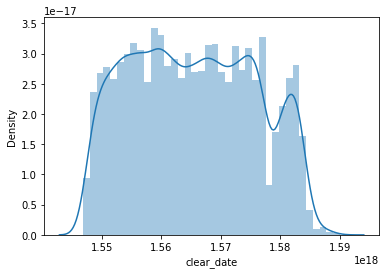

In [102]:
# distribution of the target column 
# right skewed distribution
# outliers present but not that significant , hence  
sns.distplot(y_train)

In [103]:
X_train.merge(y_train,on = X_train.index)

,key_0,business_code,cust_number,name_customer,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,Delay,clear_date
0,1,U001,0200729828,KENNETH foundation,2019.0,1.929826e+09,2019-09-06,20190903,20190906,20190926.0,USD,RV,27848.46,20190906.0,NAD1,1.929826e+09,20.0,2019-09-25
1,3,U001,0200780383,MEIJ us,2019.0,1.929852e+09,2019-09-09,20190909,20190909,20190924.0,USD,RV,81781.59,20190909.0,NAA8,1.929852e+09,15.0,2019-09-30
2,4,U001,0200792293,UNIFIE llc,2019.0,1.930113e+09,2019-11-05,20191105,20191105,20191120.0,USD,RV,67352.17,20191105.0,NAA8,1.930113e+09,15.0,2019-11-22
3,5,U001,0200833713,JETRO llc,2019.0,1.929002e+09,2019-03-20,20190320,20190320,20190404.0,USD,RV,1696.56,20190320.0,NAA8,1.929002e+09,84.0,2019-04-09
4,6,U001,0200769623,WAL-MAR corp,2020.0,1.930510e+09,2020-02-10,20200210,20200210,20200225.0,USD,RV,14213.45,20200210.0,NAH4,1.930510e+09,15.0,2020-02-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27988,35095,U001,0200769623,WAL-MAR,2019.0,1.930169e+09,2019-11-19,20191119,20191119,20191204.0,USD,RV,45839.94,20191119.0,NAH4,1.930169e+09,85.0,2019-12-02
27989,35096,U001,0200769623,WAL-MAR corp,2019.0,1.928914e+09,2019-03-07,20190306,20190307,20190322.0,USD,RV,756.28,20190307.0,NAH4,1.928914e+09,15.0,2019-03-18
27990,35097,U013,CC6530,HEINZ trust,2019.0,1.991821e+09,2019-01-24,20190124,20190124,20190310.0,USD,RV,18755.43,20190124.0,NAVF,1.991821e+09,186.0,2019-03-22
27991,35098,U001,0200881076,ALBERT trust,2019.0,1.929456e+09,2019-06-07,20190607,20190607,20190622.0,USD,RV,165.63,20190607.0,NAA8,1.929456e+09,15.0,2019-06-24


In [104]:
X_train.cust_number.nunique()

1216

In [105]:
# Creating function to change alphaNumeric to numeric
def toNumeric(numStr):
    num = 0
    for i, c in enumerate(reversed(numStr)):
        num += numStr.index(c) * (len(numStr) ** i)
    return(num)

In [106]:
# applying the function to customer_number column
for cust, group in main_train.groupby(['cust_number']):
#     print(cust, cust.isalnum(), cust.isnumeric(), cust.isalpha())
    if(cust.isnumeric() == False or cust.isalpha == False):
        print('IF')
#         X_train['cust_number'] = toNumeric(cust)
#         print(X_train['cust_number'])
    else:
        print('Else')
        X_train['cust_number'].astype(int)
        print(X_train['cust_number'])
        
        
#     X_train['cust_number'].astype(int)
#     print(X_train['cust_number'])

#     print(cust.isnumeric() == False or cust.isalpha == False)

Else


ValueError: invalid literal for int() with base 10: 'CCU013'

In [30]:
X_train

,business_code,cust_number,name_customer,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,Delay
1,U001,569,KENNETH foundation,2019.0,1.929826e+09,2019-09-06,20190903,20190906,20190926.0,USD,RV,27848.46,20190906.0,NAD1,1.929826e+09,20.0
3,U001,569,MEIJ us,2019.0,1.929852e+09,2019-09-09,20190909,20190909,20190924.0,USD,RV,81781.59,20190909.0,NAA8,1.929852e+09,15.0
4,U001,569,UNIFIE llc,2019.0,1.930113e+09,2019-11-05,20191105,20191105,20191120.0,USD,RV,67352.17,20191105.0,NAA8,1.930113e+09,15.0
5,U001,569,JETRO llc,2019.0,1.929002e+09,2019-03-20,20190320,20190320,20190404.0,USD,RV,1696.56,20190320.0,NAA8,1.929002e+09,84.0
6,U001,569,WAL-MAR corp,2020.0,1.930510e+09,2020-02-10,20200210,20200210,20200225.0,USD,RV,14213.45,20200210.0,NAH4,1.930510e+09,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35095,U001,569,WAL-MAR,2019.0,1.930169e+09,2019-11-19,20191119,20191119,20191204.0,USD,RV,45839.94,20191119.0,NAH4,1.930169e+09,85.0
35096,U001,569,WAL-MAR corp,2019.0,1.928914e+09,2019-03-07,20190306,20190307,20190322.0,USD,RV,756.28,20190307.0,NAH4,1.928914e+09,15.0
35097,U013,569,HEINZ trust,2019.0,1.991821e+09,2019-01-24,20190124,20190124,20190310.0,USD,RV,18755.43,20190124.0,NAVF,1.991821e+09,186.0
35098,U001,569,ALBERT trust,2019.0,1.929456e+09,2019-06-07,20190607,20190607,20190622.0,USD,RV,165.63,20190607.0,NAA8,1.929456e+09,15.0


In [30]:
# grouping business_code, cust_number with clear_date

X_train.merge(y_train,on = X_train.index).groupby(['cust_number', 'business_code'])['clear_date'].agg(['min']).unstack().T.idxmin()

cust_number
569    (min, U001)
dtype: object

# Feature Engg

In [28]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 27993 entries, 1 to 35099
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   business_code           27993 non-null  object        
 1   cust_number             27993 non-null  object        
 2   name_customer           27993 non-null  object        
 3   buisness_year           27993 non-null  float64       
 4   doc_id                  27993 non-null  float64       
 5   posting_date            27993 non-null  datetime64[ns]
 6   document_create_date    27993 non-null  int64         
 7   document_create_date.1  27993 non-null  int64         
 8   due_in_date             27993 non-null  float64       
 9   invoice_currency        27993 non-null  object        
 10  document type           27993 non-null  object        
 11  total_open_amount       27993 non-null  float64       
 12  baseline_create_date    27993 non-null  float6

In [29]:
from sklearn.preprocessing import LabelEncoder
Airline_encoder = LabelEncoder()
Airline_encoder.fit(X_train['business_code'])
X_train['business_code_enc'] = Airline_encoder.transform(X_train['business_code'])

In [30]:
X_train[['business_code_enc','business_code']]

,business_code_enc,business_code
1,1,U001
3,1,U001
4,1,U001
5,1,U001
6,1,U001
...,...,...
35095,1,U001
35096,1,U001
35097,4,U013
35098,1,U001


In [31]:
X_val['business_code_enc'] = Airline_encoder.transform(X_val['business_code'])
X_test['business_code_enc'] = Airline_encoder.transform(X_test['business_code'])

In [32]:
X_test[['business_code_enc','business_code']]

,business_code_enc,business_code
42592,1,U001
42593,1,U001
42594,1,U001
42598,1,U001
42599,1,U001
...,...,...
49994,1,U001
49995,1,U001
49996,1,U001
49998,1,U001


In [33]:
# Droping business_code column after encoding
X_train.drop(['business_code'], axis =1,inplace=True)
X_val.drop(['business_code'],axis=1 , inplace=True)
X_test.drop(['business_code'],axis=1 , inplace=True)

In [34]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 27993 entries, 1 to 35099
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   cust_number             27993 non-null  object        
 1   name_customer           27993 non-null  object        
 2   buisness_year           27993 non-null  float64       
 3   doc_id                  27993 non-null  float64       
 4   posting_date            27993 non-null  datetime64[ns]
 5   document_create_date    27993 non-null  int64         
 6   document_create_date.1  27993 non-null  int64         
 7   due_in_date             27993 non-null  float64       
 8   invoice_currency        27993 non-null  object        
 9   document type           27993 non-null  object        
 10  total_open_amount       27993 non-null  float64       
 11  baseline_create_date    27993 non-null  float64       
 12  cust_payment_terms      27993 non-null  object

In [35]:
# function will delete a column from train , val and test
def origin_snap(col ,traindf = X_train,valdf = X_val,testdf = X_test):
    traindf.drop(col, axis =1,inplace=True)
    valdf.drop(col,axis=1 , inplace=True)
    testdf.drop(col,axis=1 , inplace=True)

    return traindf,valdf ,testdf

In [36]:
# wrote a custom function to do a status check  on all the dataframes 
def status_check(traindf = X_train,valdf = X_val,testdf = X_test):
    print(traindf.info())
    print("-----------------------------")
    print(traindf.shape,valdf.shape,testdf.shape)
    print("-------------Train Null Count---------------")
    print(traindf.isna().sum())
    print("-------------Test Null Count---------------")
    print(testdf.isna().sum())    
    print("-------------Val Null Count---------------")
    print(valdf.isna().sum())

In [37]:
#Date of journey
#0 --> Monday , 6 --> Sunday
X_train['day_of_posting_week'] = X_train['posting_date'].dt.weekday 
X_val['day_of_posting_week'] = X_val['posting_date'].dt.weekday 
X_test['day_of_posting_week'] = X_test['posting_date'].dt.weekday

In [38]:
#extract day,month and year 

X_train['day_of_posting'] = X_train['posting_date'].dt.day
X_train['month_of_posting'] = X_train['posting_date'].dt.month
X_train['year_of_posting'] = X_train['posting_date'].dt.year

X_val['day_of_posting'] = X_val['posting_date'].dt.day
X_val['month_of_posting'] = X_val['posting_date'].dt.month
X_val['year_of_posting'] = X_val['posting_date'].dt.year


X_test['day_of_posting'] = X_test['posting_date'].dt.day
X_test['month_of_posting'] = X_test['posting_date'].dt.month
X_test['year_of_posting'] = X_test['posting_date'].dt.year

In [39]:
X_train ,X_val, X_test = origin_snap(['posting_date'])

In [40]:
# label encode invoice_currency and cust_payment_terms      
invoice_currency_encoder = LabelEncoder()
cust_payment_terms_encoder = LabelEncoder()

invoice_currency_encoder.fit(X_train['invoice_currency'])
cust_payment_terms_encoder.fit(X_train['cust_payment_terms'])

X_train['invoice_currency_enc'] = invoice_currency_encoder.transform(X_train['invoice_currency'])
X_train['cust_payment_terms_enc'] = cust_payment_terms_encoder.transform(X_train['cust_payment_terms'])

X_val['invoice_currency_enc'] = invoice_currency_encoder.transform(X_val['invoice_currency'])
X_val['cust_payment_terms_enc'] = cust_payment_terms_encoder.transform(X_val['cust_payment_terms'])

X_test['invoice_currency_enc'] = invoice_currency_encoder.transform(X_test['invoice_currency'])
X_test['cust_payment_terms_enc'] = cust_payment_terms_encoder.transform(X_test['cust_payment_terms'])

In [42]:
X_train ,X_val, X_test = origin_snap(['invoice_currency','cust_payment_terms'])

In [50]:
status_check() # X_train ,X_val, X_test = origin_snap(['name_customer','document type'])

<class 'pandas.core.frame.DataFrame'>
Int64Index: 27993 entries, 1 to 35099
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cust_number             27993 non-null  int64  
 1   buisness_year           27993 non-null  float64
 2   doc_id                  27993 non-null  float64
 3   document_create_date    27993 non-null  int64  
 4   document_create_date.1  27993 non-null  int64  
 5   due_in_date             27993 non-null  float64
 6   total_open_amount       27993 non-null  float64
 7   baseline_create_date    27993 non-null  float64
 8   invoice_id              27993 non-null  float64
 9   Delay                   27993 non-null  float64
 10  business_code_enc       27993 non-null  int32  
 11  day_of_posting_week     27993 non-null  int64  
 12  day_of_posting          27993 non-null  int64  
 13  month_of_posting        27993 non-null  int64  
 14  year_of_posting         27993 non-null

# Feature Selection

<AxesSubplot:title={'center':'Pearson Correlation of Features'}>

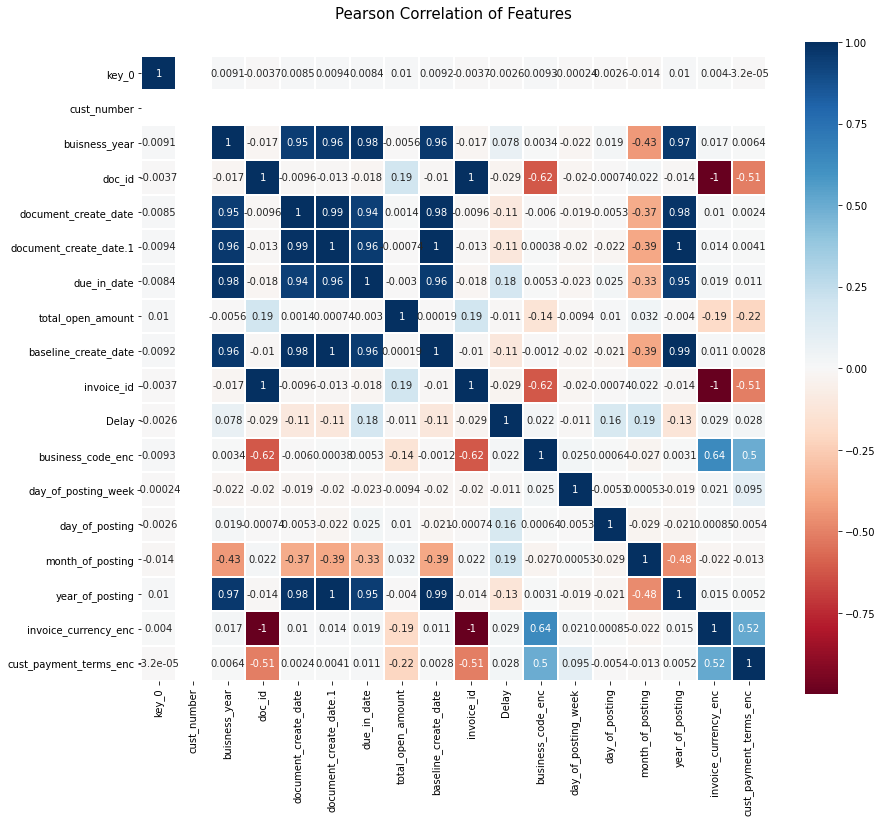

In [51]:
# Checking the correlation of columns

colormap = plt.cm.RdBu
plt.figure(figsize=(14,12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.heatmap(X_train.merge(y_train , on = X_train.index ).corr(),linewidths=0.1,vmax=1.0, 
            square=True, cmap=colormap, linecolor='white', annot=True)